# **Titanic Passenger Survival Prediction**

## 1. Problem Statement


During the Titanic disaster, passenger survival depended on several factors such as age, gender, and passenger class.
The goal of this project is to develop a binary classification machine learning model that predicts whether a passenger survived (Yes/No) using historical passenger data. The project also aims to identify the most important factors that influenced survival.

## 2. Objectives of the Project




* Understand passenger survival patterns
* Perform basic data preprocessing
* Conduct minimal but meaningful EDA
* Build binary classification models
* Evaluate model performance
* Identify key survival-influencing features







## 3. Dataset Description

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [4]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [5]:
import pandas as pd
df = pd.read_csv("train.csv")
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

## 4. Exploratory Data Analysis (EDA) - Minimal Graphs

### Graph 1 : Survival Count Plot

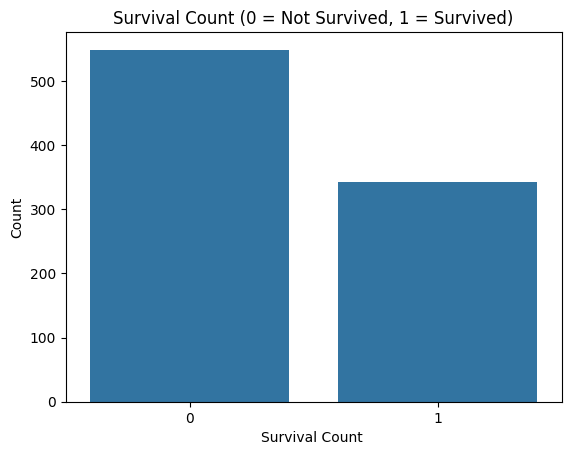

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0 = Not Survived, 1 = Survived)')
plt.xlabel("Survival Count ")
plt.ylabel("Count")
plt.show()

### Graph 2 : Survival by Gender

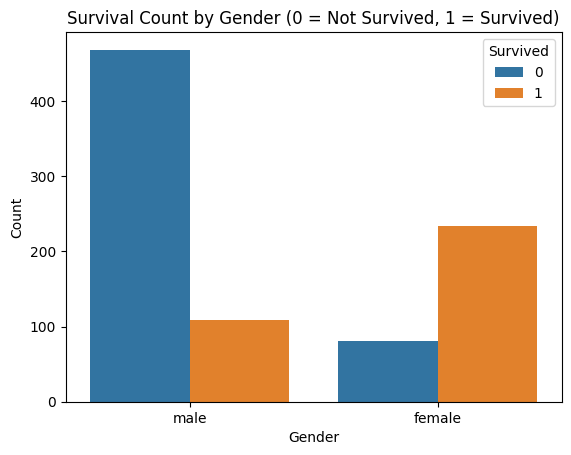

In [7]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender (0 = Not Survived, 1 = Survived)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Graph 3 : Survival by Passenger class

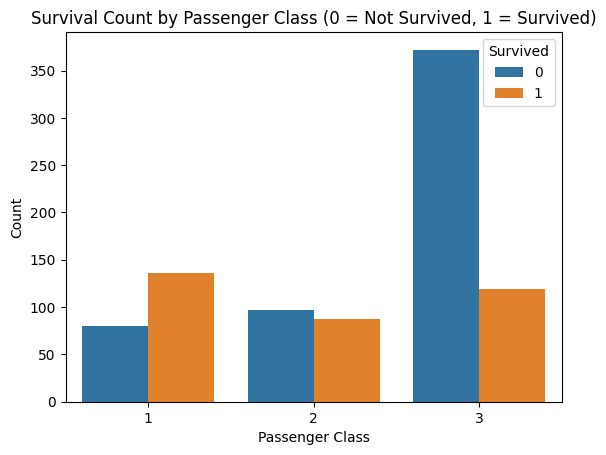

In [8]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class (0 = Not Survived, 1 = Survived)')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

### Graph 4 : Fare vs Survival

Text(0, 0.5, 'Fare')

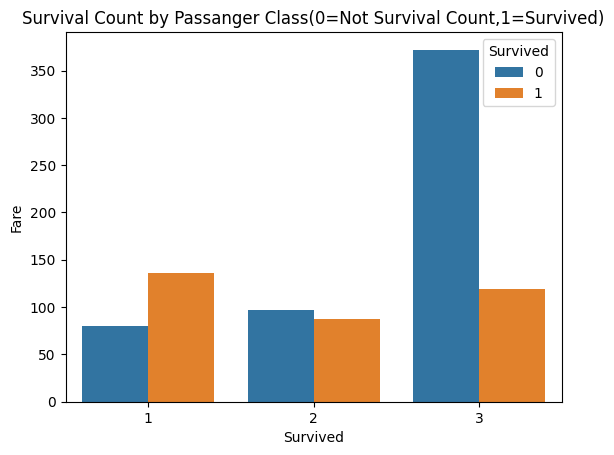

In [9]:
sns.countplot(x='Pclass',hue="Survived",data=df)
plt.title('Survival Count by Passanger Class(0=Not Survival Count,1=Survived)')
plt.xlabel("Survived")
plt.ylabel("Fare")

## 5. Machine Learning Workflow

In [10]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [11]:
import pandas as pd
df = pd.read_csv("train.csv")
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df["Age"] = df['Age'].fillna(df['Age'].median())
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [14]:
cat_cols=["Embarked"]
for col in cat_cols:
  df[col]=df[col].fillna(df[col].mode()[0])
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df.drop('Cabin', axis=1, inplace=True)
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [17]:
# Encode categorical variables (Sex, Embarked)
df['Sex'] = df['Sex'].map({'male':1,'female':0})
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name  Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    1  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1   
2                               Heikkinen, Miss. Laina    0  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1   
4                             Allen, Mr. William Henry    1  35.0      0   
..                                                 ...  ...   ...    ...   
886        

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Embarked']=le.fit_transform(df['Embarked'])
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name  Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    1  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1   
2                               Heikkinen, Miss. Laina    0  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1   
4                             Allen, Mr. William Henry    1  35.0      0   
..                                                 ...  ...   ...    ...   
886        

In [19]:
# Scale Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

In [20]:
df.drop(['PassengerId','Name','Ticket',], axis=1, inplace=True)

In [21]:
df.to_csv("cleaned_titanic_dataset.csv", index=False)
from google.colab import files
files.download("cleaned_titanic_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## 6. Models Used

### Logistic Regression

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### Decision Tree

In [25]:
model = DecisionTreeClassifier(criterion='gini', max_depth=4)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

### Random Forest

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    bootstrap=True,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

## 7. Model Evaluation

### Graph 5 : Confusion Matrix

In [27]:
y_pred = model.predict(X_test)
print(y_pred)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 1
 0]
[[119  15]
 [ 28  61]]


In [28]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1_Score:",f1_score(y_test,y_pred))

Accuracy: 0.8071748878923767
Precision: 0.8026315789473685
Recall: 0.6853932584269663
F1_Score: 0.7393939393939394


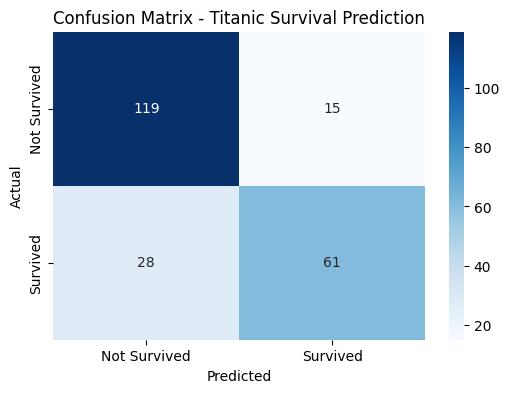

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Titanic Survival Prediction')
plt.show()

## 8. Identifying Survival-Influencing Factors

In [30]:
importances = rf.feature_importances_
feature_names = X.columns

feature_importtance_df = pd.DataFrame({
    'Feature' : feature_names,
    'Importance' : importances
})

### Graph 6: Feature Importance (Random Forest)

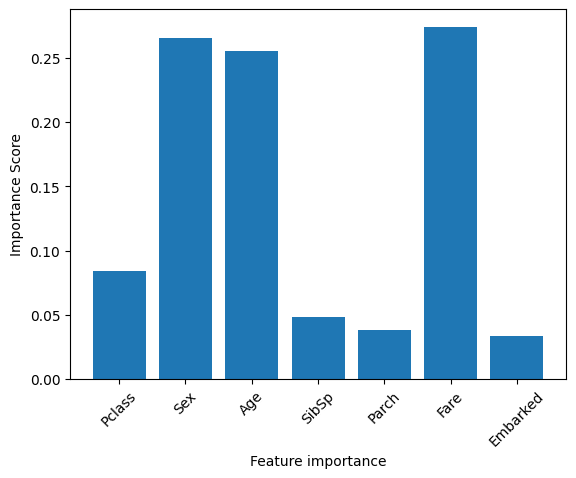

In [31]:
plt.figure()
plt.bar(feature_names,importances)
plt.ylabel("Importance Score")
plt.xlabel("Feature importance")
plt.xticks(rotation=45)
plt.show()